# Weather Data Preprocessing

In [1]:
# Import required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import builtins
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")


Libraries imported successfully


In [2]:
# Create Spark Session
spark = SparkSession.builder \
    .appName("CrimeWeatherEDA") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark session created successfully")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/11/28 20:40:55 WARN Utils: Your hostname, MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.165 instead (on interface en0)
25/11/28 20:40:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/28 20:40:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session created successfully


## 1. Weather Data EDA


In [3]:
# Load weather data
# Update the path to your weather CSV file
weather_path = "/Users/tripa/Desktop/BU/Fall 2025/Big data/Term Project/boston-weather.csv"

df = spark.read.csv(weather_path, header=True, inferSchema=True)

print(f"Data loaded: {df.count()} rows, {len(df.columns)} columns")
df.show(5, truncate=False)


Data loaded: 1460 rows, 6 columns
+----------+--------+-------+-------------+----------+---------------+
|Day       |High(°F)|Low(°F)|Precip.(inch)|Snow(inch)|Snowdepth(inch)|
+----------+--------+-------+-------------+----------+---------------+
|1 jan 2015|33.1    |22.1   |0.00         |0.00      |-              |
|2 jan 2015|41.0    |31.1   |0.00         |0.00      |-              |
|3 jan 2015|37.0    |22.1   |0.62         |1.42      |-              |
|4 jan 2015|52.0    |35.1   |0.57         |0.00      |-              |
|5 jan 2015|50.0    |17.2   |0.00         |0.00      |-              |
+----------+--------+-------+-------------+----------+---------------+
only showing top 5 rows


In [4]:
# Display schema
df.printSchema()


root
 |-- Day: string (nullable = true)
 |-- High(°F): string (nullable = true)
 |-- Low(°F): string (nullable = true)
 |-- Precip.(inch): string (nullable = true)
 |-- Snow(inch): string (nullable = true)
 |-- Snowdepth(inch): string (nullable = true)



In [5]:
# Standardize column names (lowercase, replace spaces with underscores)
df = df.toDF(*[c.lower().replace(" ", "_").replace("(", "").replace(")", "").replace(".", "_") for c in df.columns])
print("Column names standardized")
df.show(5, truncate=False)


Column names standardized
+----------+------+-----+-----------+--------+-------------+
|day       |high°f|low°f|precip_inch|snowinch|snowdepthinch|
+----------+------+-----+-----------+--------+-------------+
|1 jan 2015|33.1  |22.1 |0.00       |0.00    |-            |
|2 jan 2015|41.0  |31.1 |0.00       |0.00    |-            |
|3 jan 2015|37.0  |22.1 |0.62       |1.42    |-            |
|4 jan 2015|52.0  |35.1 |0.57       |0.00    |-            |
|5 jan 2015|50.0  |17.2 |0.00       |0.00    |-            |
+----------+------+-----+-----------+--------+-------------+
only showing top 5 rows


In [6]:
# Check for missing values
from pyspark.sql.functions import col, sum as spark_sum

missing_values = df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
print("Missing values per column:")
missing_values.show(vertical=True)


Missing values per column:
-RECORD 0------------
 day           | 0   
 high°f        | 0   
 low°f         | 0   
 precip_inch   | 0   
 snowinch      | 0   
 snowdepthinch | 0   



In [7]:
# Clean and convert date column
# Handle date parsing - adjust format based on your data
df = df.withColumn("date_parsed", 
                   to_date(col("day"), "d MMM yyyy"))

# Filter out invalid dates
df = df.filter(col("date_parsed").isNotNull())

# Extract date components
df = df.withColumn("year", year(col("date_parsed"))) \
       .withColumn("month", month(col("date_parsed"))) \
       .withColumn("day_of_month", dayofmonth(col("date_parsed"))) \
       .withColumn("day_of_week", date_format(col("date_parsed"), "E")) \
       .withColumn("quarter", quarter(col("date_parsed")))

print("Date parsing and feature extraction complete")
df.select("day", "date_parsed", "year", "month", "day_of_week", "quarter").show(10)


Date parsing and feature extraction complete
+-----------+-----------+----+-----+-----------+-------+
|        day|date_parsed|year|month|day_of_week|quarter|
+-----------+-----------+----+-----+-----------+-------+
| 1 jan 2015| 2015-01-01|2015|    1|        Thu|      1|
| 2 jan 2015| 2015-01-02|2015|    1|        Fri|      1|
| 3 jan 2015| 2015-01-03|2015|    1|        Sat|      1|
| 4 jan 2015| 2015-01-04|2015|    1|        Sun|      1|
| 5 jan 2015| 2015-01-05|2015|    1|        Mon|      1|
| 6 jan 2015| 2015-01-06|2015|    1|        Tue|      1|
| 7 jan 2015| 2015-01-07|2015|    1|        Wed|      1|
| 8 jan 2015| 2015-01-08|2015|    1|        Thu|      1|
| 9 jan 2015| 2015-01-09|2015|    1|        Fri|      1|
|10 jan 2015| 2015-01-10|2015|    1|        Sat|      1|
+-----------+-----------+----+-----+-----------+-------+
only showing top 10 rows


In [8]:
# Re-standardize column names to handle degree symbol and other special characters
def standardize_col_name(name):
    """Standardize column names by handling special characters"""
    name = name.lower()
    name = name.replace(" ", "_")
    name = name.replace("(", "_")  # Add underscore before removing
    name = name.replace(")", "")
    name = name.replace(".", "_")
    name = name.replace("°", "_")  # Handle degree symbol
    # Clean up multiple underscores
    while "__" in name:
        name = name.replace("__", "_")
    # Remove trailing underscores
    name = name.rstrip("_")
    return name

# Get current column names and create mapping
current_cols = df.columns
new_cols = [standardize_col_name(c) for c in current_cols]

# Rename columns if needed
column_mapping = {}
for old_col, new_col in zip(current_cols, new_cols):
    if old_col != new_col:
        df = df.withColumnRenamed(old_col, new_col)
        column_mapping[old_col] = new_col

if column_mapping:
    print(f"Column names re-standardized: {column_mapping}")
    print(f"Current columns: {df.columns}")

# CRITICAL FIX: Reload numeric columns as strings to avoid type inference issues
# This prevents Spark from trying to cast 'T' to double during schema inference
weather_path = "/Users/tripa/Desktop/BU/Fall 2025/Big data/Term Project/boston-weather.csv"
df_strings = spark.read.csv(weather_path, header=True, inferSchema=False)  # Read as strings!

# Standardize column names for the string dataframe
df_strings = df_strings.toDF(*[standardize_col_name(c) for c in df_strings.columns])

# Get the date column from original df (already parsed)
df_date = df.select("day", "date_parsed", "year", "month", "day_of_month", "day_of_week", "quarter")

# Clean numeric columns - handle special values like 'T' (trace), '-' (missing)
numeric_cols = ['high_f', 'low_f', 'precip_inch', 'snow_inch', 'snowdepth_inch']

# Check which columns actually exist
available_numeric_cols = []
for col_name in numeric_cols:
    if col_name in df_strings.columns:
        available_numeric_cols.append(col_name)
    elif col_name == 'snow_inch' and 'snowinch' in df_strings.columns:
        df_strings = df_strings.withColumnRenamed('snowinch', 'snow_inch')
        available_numeric_cols.append('snow_inch')
    elif col_name == 'snowdepth_inch' and 'snowdepthinch' in df_strings.columns:
        df_strings = df_strings.withColumnRenamed('snowdepthinch', 'snowdepth_inch')
        available_numeric_cols.append('snowdepth_inch')

print(f"Processing numeric columns: {available_numeric_cols}")

# Now clean the numeric columns from the string dataframe
for col_name in available_numeric_cols:
    if col_name in df_strings.columns:
        # Trim and replace special values
        col_cleaned = trim(df_strings[col_name])
        col_cleaned = regexp_replace(col_cleaned, '^T$', '0.001')  # Replace 'T' with '0.001'
        col_cleaned = regexp_replace(col_cleaned, '^-$', '')  # Replace '-' with empty
        
        # Cast to double - empty strings become NULL
        df_strings = df_strings.withColumn(col_name, 
                                          when(col_cleaned == '', None)
                                          .otherwise(col_cleaned.cast("double")))

# Join back with date columns
df = df_strings.join(df_date, on="day", how="inner")

print("Numeric columns cleaned and converted")
df.select(available_numeric_cols).show(10)


Column names re-standardized: {'high°f': 'high_f', 'low°f': 'low_f'}
Current columns: ['day', 'high_f', 'low_f', 'precip_inch', 'snowinch', 'snowdepthinch', 'date_parsed', 'year', 'month', 'day_of_month', 'day_of_week', 'quarter']
Processing numeric columns: ['high_f', 'low_f', 'precip_inch', 'snow_inch', 'snowdepth_inch']
Numeric columns cleaned and converted
+------+-----+-----------+---------+--------------+
|high_f|low_f|precip_inch|snow_inch|snowdepth_inch|
+------+-----+-----------+---------+--------------+
|  33.1| 22.1|        0.0|      0.0|          NULL|
|  41.0| 31.1|        0.0|      0.0|          NULL|
|  37.0| 22.1|       0.62|     1.42|          NULL|
|  52.0| 35.1|       0.57|      0.0|          NULL|
|  50.0| 17.2|        0.0|      0.0|          NULL|
|  18.1| 15.3|       0.02|      0.2|          NULL|
|  26.2|  4.1|      0.001|    0.001|          NULL|
|  19.2| -0.8|        0.0|      0.0|          NULL|
|  30.2| 19.2|       0.01|      0.2|          NULL|
|  24.3| 17.2

In [9]:
# Handle missing values - fill numeric columns with mean
for col_name in numeric_cols:
    if col_name in df.columns:
        mean_val = df.filter(col(col_name).isNotNull()).agg(mean(col(col_name))).first()[0]
        if mean_val is not None:
            df = df.fillna({col_name: mean_val})
            print(f"Filled missing values in {col_name} with mean: {mean_val:.2f}")

print("Missing value imputation complete")


Filled missing values in high_f with mean: 60.30
Filled missing values in low_f with mean: 45.23
Filled missing values in precip_inch with mean: 0.11
Filled missing values in snow_inch with mean: 0.17
Filled missing values in snowdepth_inch with mean: 0.00
Missing value imputation complete


In [10]:
# Remove duplicates
initial_count = df.count()
df = df.dropDuplicates()
final_count = df.count()
print(f"Removed {initial_count - final_count} duplicate records")
print(f"Final record count: {final_count}")


Removed 0 duplicate records
Final record count: 1460


In [11]:
# Descriptive statistics
print("Descriptive Statistics for Numeric Columns:")
df.select(numeric_cols).describe().show()


Descriptive Statistics for Numeric Columns:


25/11/28 20:41:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+-------------------+-------------------+--------------+
|summary|            high_f|             low_f|        precip_inch|          snow_inch|snowdepth_inch|
+-------+------------------+------------------+-------------------+-------------------+--------------+
|  count|              1460|              1460|               1460|               1460|          1460|
|   mean|60.303015764222074| 45.22803289924582|0.11265181631254323|0.16995374912403655|           0.0|
| stddev|18.852057167462174|17.337363002990912|0.28588897839231336| 1.2015253045765018|           0.0|
|    min|              12.2|              -8.9|                0.0|                0.0|           0.0|
|    max|              98.1|              81.0|               2.68|              22.09|           0.0|
+-------+------------------+------------------+-------------------+-------------------+--------------+



In [12]:
# Feature Engineering: Calculate temperature range
df = df.withColumn("temp_range", col("high_f") - col("low_f"))

# Create season column
df = df.withColumn("season",
                   when(col("month").isin([12, 1, 2]), "Winter")
                   .when(col("month").isin([3, 4, 5]), "Spring")
                   .when(col("month").isin([6, 7, 8]), "Summer")
                   .otherwise("Fall"))

# Create temperature categories
df = df.withColumn("temp_category",
                   when(col("high_f") < 32, "Freezing")
                   .when(col("high_f") < 50, "Cold")
                   .when(col("high_f") < 70, "Cool")
                   .when(col("high_f") < 85, "Warm")
                   .otherwise("Hot"))

# Precipitation flag
df = df.withColumn("has_precipitation", 
                   when(col("precip_inch") > 0, 1).otherwise(0))

# Snow flag
df = df.withColumn("has_snow", 
                   when(col("snow_inch") > 0, 1).otherwise(0))

print("Feature engineering complete")
df.select("date_parsed", "season", "temp_category", "temp_range", 
          "has_precipitation", "has_snow").show(10)


Feature engineering complete
+-----------+------+-------------+------------------+-----------------+--------+
|date_parsed|season|temp_category|        temp_range|has_precipitation|has_snow|
+-----------+------+-------------+------------------+-----------------+--------+
| 2015-04-05|Spring|         Cold|              16.9|                0|       0|
| 2015-04-08|Spring|         Cold| 8.100000000000001|                1|       1|
| 2016-01-14|Winter|     Freezing|               9.0|                1|       1|
| 2016-03-28|Spring|         Cold|               9.0|                1|       0|
| 2016-05-26|Spring|         Warm|              21.1|                0|       0|
| 2016-07-11|Summer|         Warm|              13.0|                1|       0|
| 2016-09-17|  Fall|         Warm|23.099999999999994|                0|       0|
| 2018-01-23|Winter|         Cool|              23.0|                1|       0|
| 2018-03-12|Spring|         Cold|              13.0|                1|       0|

In [13]:
# Aggregations by season
print("Average Temperature by Season:")
df.groupBy("season") \
  .agg(avg("high_f").alias("avg_high"),
       avg("low_f").alias("avg_low"),
       avg("temp_range").alias("avg_range"),
       sum("has_precipitation").alias("precip_days"),
       sum("has_snow").alias("snow_days")) \
  .orderBy("season") \
  .show()


Average Temperature by Season:
+------+-----------------+------------------+------------------+-----------+---------+
|season|         avg_high|           avg_low|         avg_range|precip_days|snow_days|
+------+-----------------+------------------+------------------+-----------+---------+
|  Fall|63.78159340659343|49.458791208791176|14.322802197802195|        166|       10|
|Spring|56.04211956521736| 40.40190217391309|15.640217391304363|        184|       47|
|Summer|80.44673913043479|  64.5290760869565| 15.91766304347826|        163|        1|
|Winter|40.55000837712289|26.153688980275735|14.396319396847161|        177|      133|
+------+-----------------+------------------+------------------+-----------+---------+



In [14]:
# Time series analysis - monthly averages
monthly_stats = df.groupBy("year", "month") \
                  .agg(avg("high_f").alias("avg_high"),
                       avg("low_f").alias("avg_low"),
                       avg("precip_inch").alias("avg_precip"),
                       sum("has_precipitation").alias("precip_days")) \
                  .orderBy("year", "month")

print("Monthly Statistics (first 20 rows):")
monthly_stats.show(20)


Monthly Statistics (first 20 rows):
+----+-----+------------------+------------------+--------------------+-----------+
|year|month|          avg_high|           avg_low|          avg_precip|precip_days|
+----+-----+------------------+------------------+--------------------+-----------+
|2015|    1| 33.20322580645162| 19.16129032258065| 0.11529032258064513|         17|
|2015|    2|27.942857142857154| 10.33928571428571|  0.1204285714285714|         20|
|2015|    3|40.932258064516134| 25.66129032258065| 0.09848387096774194|         18|
|2015|    4| 55.76333333333333| 40.25333333333334| 0.07606666666666669|         14|
|2015|    5| 73.18709677419353| 51.38387096774194|0.039483870967741926|          8|
|2015|    6|             72.04|57.269999999999996|  0.1672333333333333|         16|
|2015|    7| 81.52258064516128| 66.23548387096773| 0.06767741935483867|         17|
|2015|    8| 82.70322580645161| 66.57741935483872| 0.07077419354838708|         10|
|2015|    9|             77.41| 60.99666

In [15]:
# Correlation analysis
# Convert to pandas for correlation matrix (for smaller datasets)
# For large datasets, use Spark's correlation functions

# Sample data for correlation (if dataset is large, sample it)
# Use built-in min to avoid conflict with PySpark's min function
import builtins
total_count = df.count()
sample_size = builtins.min(100, total_count)
df_sample = df.sample(False, sample_size / total_count, seed=42)

# Get numeric columns for correlation
numeric_cols_for_corr = ['high_f', 'low_f', 'precip_inch', 'snow_inch', 'temp_range']
available_cols = [c for c in numeric_cols_for_corr if c in df_sample.columns]

if len(available_cols) > 1:
    # Calculate pairwise correlations using Spark
    from pyspark.ml.stat import Correlation
    from pyspark.ml.feature import VectorAssembler
    
    assembler = VectorAssembler(inputCols=available_cols, outputCol="features")
    df_vector = assembler.transform(df_sample.select(available_cols))
    
    # Calculate correlation matrix
    correlation_matrix = Correlation.corr(df_vector, "features").head()[0]
    
    print("Correlation Matrix:")
    print(correlation_matrix.toArray())
    
    # Convert to pandas for better visualization
    import numpy as np
    corr_df = pd.DataFrame(
        correlation_matrix.toArray(),
        columns=available_cols,
        index=available_cols
    )
    print("\nCorrelation DataFrame:")
    print(corr_df)


Correlation Matrix:
[[ 1.          0.92870137 -0.02588333 -0.2734315   0.40643834]
 [ 0.92870137  1.          0.00756035 -0.24632908  0.03864194]
 [-0.02588333  0.00756035  1.          0.37269744 -0.08837434]
 [-0.2734315  -0.24632908  0.37269744  1.         -0.12987613]
 [ 0.40643834  0.03864194 -0.08837434 -0.12987613  1.        ]]

Correlation DataFrame:
               high_f     low_f  precip_inch  snow_inch  temp_range
high_f       1.000000  0.928701    -0.025883  -0.273431    0.406438
low_f        0.928701  1.000000     0.007560  -0.246329    0.038642
precip_inch -0.025883  0.007560     1.000000   0.372697   -0.088374
snow_inch   -0.273431 -0.246329     0.372697   1.000000   -0.129876
temp_range   0.406438  0.038642    -0.088374  -0.129876    1.000000


25/11/28 20:41:08 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


## Crime Data Preprocess

In [ ]:
"""
PySpark Crime Data Preprocessing
Clean, efficient preprocessing with all key features included
"""

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

# CONFIGURATION
path="/Users/tripa/Desktop/BU/Fall 2025/Big data/Term Project/"
INPUT_PATH = path + "crime.csv"
OUTPUT_PATH = path + "preprocessed_crime_data"

# PREPROCESSING PIPELINE

print("PySpark Crime Data Preprocessing Pipeline")

# Create Spark Session
spark = SparkSession.builder \
    .appName("CrimePreprocessing") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

# Load Data
print("\nLoading data:")
df = spark.read.csv(INPUT_PATH, header=True, inferSchema=True, nullValue="", nanValue="NaN")
print(f"Loaded {df.count()} records with {len(df.columns)} columns")

# Remove Duplicates
print("\nRemoving duplicates")
initial_count = df.count()
df = df.dropDuplicates()
print(f"Removed {initial_count - df.count()} duplicate records")

# Clean String Columns
print("\nCleaning string columns")
string_cols = ['INCIDENT_NUMBER', 'OFFENSE_CODE_GROUP', 'OFFENSE_DESCRIPTION', 
               'DISTRICT', 'UCR_PART', 'STREET', 'DAY_OF_WEEK']
for col_name in string_cols:
    if col_name in df.columns:
        df = df.withColumn(col_name, trim(col(col_name)))
print(f"Cleaned {len(string_cols)} string columns")

# Convert Data Types & Handle Missing Values
print("\nConverting data types and handling missing values")

# Convert timestamp
df = df.withColumn("OCCURRED_ON_DATE", to_timestamp(col("OCCURRED_ON_DATE"), "yyyy-MM-dd HH:mm:ss"))

# Create SHOOTING binary flag
df = df.withColumn("SHOOTING_FLAG", when(upper(col("SHOOTING")) == "Y", 1).otherwise(0))

# Handle coordinates
df = df.withColumn("Lat", 
                   when((col("Lat") == 0) | (col("Lat").isNull()), None)
                   .otherwise(col("Lat")))
df = df.withColumn("Long", 
                   when((col("Long") == 0) | (col("Long").isNull()), None)
                   .otherwise(col("Long")))

# Impute coordinates
lat_mean = df.filter(col("Lat").isNotNull()).agg(mean("Lat")).first()[0]
long_mean = df.filter(col("Long").isNotNull()).agg(mean("Long")).first()[0]

df = df.withColumn("Lat_Clean", coalesce(col("Lat"), lit(lat_mean)))
df = df.withColumn("Long_Clean", coalesce(col("Long"), lit(long_mean)))
df = df.withColumn("Lat_Missing_Flag", when(col("Lat").isNull(), 1).otherwise(0))
df = df.withColumn("Long_Missing_Flag", when(col("Long").isNull(), 1).otherwise(0))

# Fill missing categorical values
df = df.fillna({
    'DISTRICT': 'UNKNOWN',
    'OFFENSE_CODE_GROUP': 'Other',
    'UCR_PART': 'Unknown',
    'STREET': 'UNKNOWN',
    'REPORTING_AREA': 'UNKNOWN'
})

print(f"Converted types, imputed coordinates (Lat: {lat_mean:.6f}, Long: {long_mean:.6f})")

# 6. Feature Engineering
print("\nEngineering features")

# Time of day
df = df.withColumn("TIME_OF_DAY",
    when((col("HOUR") >= 6) & (col("HOUR") < 12), "Morning")
    .when((col("HOUR") >= 12) & (col("HOUR") < 17), "Afternoon")
    .when((col("HOUR") >= 17) & (col("HOUR") < 21), "Evening")
    .otherwise("Night"))

# Weekend indicator
df = df.withColumn("IS_WEEKEND",
    when(col("DAY_OF_WEEK").isin(["Saturday", "Sunday"]), 1).otherwise(0))

# Crime severity
df = df.withColumn("CRIME_SEVERITY",
    when(col("UCR_PART") == "Part One", 3)
    .when(col("UCR_PART") == "Part Two", 2)
    .when(col("UCR_PART") == "Part Three", 1)
    .otherwise(0))

# Season
df = df.withColumn("SEASON",
    when(col("MONTH").isin([12, 1, 2]), "Winter")
    .when(col("MONTH").isin([3, 4, 5]), "Spring")
    .when(col("MONTH").isin([6, 7, 8]), "Summer")
    .otherwise("Fall"))

# Quarter
df = df.withColumn("QUARTER",
    when(col("MONTH").isin([1, 2, 3]), 1)
    .when(col("MONTH").isin([4, 5, 6]), 2)
    .when(col("MONTH").isin([7, 8, 9]), 3)
    .otherwise(4))

# Day number
df = df.withColumn("DAY_NUMBER",
    when(col("DAY_OF_WEEK") == "Monday", 1)
    .when(col("DAY_OF_WEEK") == "Tuesday", 2)
    .when(col("DAY_OF_WEEK") == "Wednesday", 3)
    .when(col("DAY_OF_WEEK") == "Thursday", 4)
    .when(col("DAY_OF_WEEK") == "Friday", 5)
    .when(col("DAY_OF_WEEK") == "Saturday", 6)
    .when(col("DAY_OF_WEEK") == "Sunday", 7)
    .otherwise(0))

# Offense category
df = df.withColumn("OFFENSE_CATEGORY",
    when(col("OFFENSE_CODE_GROUP").contains("Assault"), "Violent")
    .when(col("OFFENSE_CODE_GROUP").contains("Robbery"), "Violent")
    .when(col("OFFENSE_CODE_GROUP").contains("Homicide"), "Violent")
    .when(col("OFFENSE_CODE_GROUP").contains("Larceny"), "Property")
    .when(col("OFFENSE_CODE_GROUP").contains("Burglary"), "Property")
    .when(col("OFFENSE_CODE_GROUP").contains("Vandalism"), "Property")
    .when(col("OFFENSE_CODE_GROUP").contains("Auto Theft"), "Property")
    .when(col("OFFENSE_CODE_GROUP").contains("Drug"), "Drug")
    .when(col("OFFENSE_CODE_GROUP").contains("Motor Vehicle"), "Traffic")
    .otherwise("Other"))

# High risk hour
df = df.withColumn("HIGH_RISK_HOUR",
    when(col("HOUR").isin([0, 1, 2, 3, 22, 23]), 1).otherwise(0))

print("Created 9 new features")

# 7. Encode Categorical Variables
print("\nEncoding categorical variables")
categorical_cols = ['DISTRICT', 'TIME_OF_DAY', 'SEASON', 'OFFENSE_CATEGORY', 'UCR_PART']

indexers = []
encoders = []

for col_name in categorical_cols:
    indexer = StringIndexer(inputCol=col_name, 
                            outputCol=f"{col_name}_Index",
                            handleInvalid="keep")
    encoder = OneHotEncoder(inputCol=f"{col_name}_Index",
                           outputCol=f"{col_name}_Encoded",
                           dropLast=True)
    indexers.append(indexer)
    encoders.append(encoder)

pipeline = Pipeline(stages=indexers + encoders)
df = pipeline.fit(df).transform(df)
print(f"Encoded {len(categorical_cols)} categorical columns")

# 8. Scale Numeric Features
print("\nScaling numeric features")
numeric_cols = ['OFFENSE_CODE', 'YEAR', 'MONTH', 'HOUR', 'QUARTER',
                'Lat_Clean', 'Long_Clean', 'DAY_NUMBER', 'CRIME_SEVERITY']

available_cols = [c for c in numeric_cols if c in df.columns]

assembler = VectorAssembler(inputCols=available_cols,
                            outputCol="numeric_features",
                            handleInvalid="skip")

scaler = StandardScaler(inputCol="numeric_features",
                       outputCol="scaled_features",
                       withMean=True,
                       withStd=True)

scale_pipeline = Pipeline(stages=[assembler, scaler])
df = scale_pipeline.fit(df).transform(df)
print(f"Scaled {len(available_cols)} numeric features")

# 9. Display Results
print("\nPreprocessing complete!")
print("PREPROCESSING SUMMARY")
print(f"Final record count: {df.count()}")
print(f"Final column count: {len(df.columns)}")

print("\nAll Features in Dataset")
print("Original Columns:", df.columns[:17])
print("\nNew Features Created:")
new_features = [
    'SHOOTING_FLAG', 'Lat_Clean', 'Long_Clean', 'Lat_Missing_Flag', 
    'Long_Missing_Flag', 'TIME_OF_DAY', 'IS_WEEKEND', 'CRIME_SEVERITY',
    'SEASON', 'QUARTER', 'DAY_NUMBER', 'OFFENSE_CATEGORY', 'HIGH_RISK_HOUR'
]
for feat in new_features:
    print(f"   {feat}")

print("\nEncoded Columns:")
for col_name in categorical_cols:
    print(f"   {col_name}_Index")
    print(f"   {col_name}_Encoded")

print("\nScaled Features:")
print(f"   numeric_features (vector of {len(available_cols)} features)")
print(f"   scaled_features (standardized)")

print("\nSample of Preprocessed Data (20 rows)")
df.select('INCIDENT_NUMBER', 'OFFENSE_CATEGORY', 'TIME_OF_DAY', 
          'CRIME_SEVERITY', 'IS_WEEKEND', 'SHOOTING_FLAG', 'SEASON', 'QUARTER').show(20, truncate=False)

print("\nDistribution of Offense Categories")
df.groupBy('OFFENSE_CATEGORY').count().orderBy(col('count').desc()).show()

print("\nDistribution of Time of Day")
df.groupBy('TIME_OF_DAY').count().orderBy(col('count').desc()).show()

# 10. Save Data
print("\nSaving preprocessed data")

# Select all columns except vector types (they can't be saved to CSV)
csv_compatible_cols = [c for c in df.columns 
                       if not c.endswith('_Encoded') 
                       and 'features' not in c.lower()
                       and c != 'Location']

csv_df = df.select(csv_compatible_cols)

# Save as single CSV file directly
csv_output_file = OUTPUT_PATH + ".csv"
print(f"\nSaving clean CSV file...")
csv_df.toPandas().to_csv(csv_output_file, index=False)
print(f"✔ Clean CSV saved to: {csv_output_file}")
print(f"    {len(csv_compatible_cols)} columns")

print("PREPROCESSING COMPLETE")

print("\n Summary:")
print(f"   • Original features: 17")
print(f"   • New features created: {len(new_features)}")
print(f"   • Encoded features: {len(categorical_cols) * 2}")
print(f"   • Total columns: {len(df.columns)}")
print(f"   • Columns in CSV: {len(csv_compatible_cols)} (vectors excluded)")

print("\n Key Features Included:")
print("    All original columns")
print("    SHOOTING_FLAG (binary)")
print("    Cleaned coordinates (Lat_Clean, Long_Clean)")
print("    Missing indicators (Lat_Missing_Flag, Long_Missing_Flag)")
print("    TIME_OF_DAY, SEASON, QUARTER")
print("    OFFENSE_CATEGORY, CRIME_SEVERITY")
print("    IS_WEEKEND, HIGH_RISK_HOUR, DAY_NUMBER")
print("    Categorical encodings (Index + OneHot)")
print("    Scaled numeric features")

print("\n Files Created:")
print(f"   {csv_output_file} - Clean CSV file")

print("\n All preprocessing complete")
spark.stop()

# Crime and Weather Correlation Analysis

This section analyzes the relationship between crime data and weather conditions.


In [ ]:
# Load crime data
path="/Users/tripa/Desktop/BU/Fall 2025/Big data/Term Project/"
crime_path = path + "preprocessed_crime_data.csv"

print("Loading crime data...")
crime_df = spark.read.csv(crime_path, header=True, inferSchema=True)

print(f"Crime data loaded: {crime_df.count()} records, {len(crime_df.columns)} columns")
crime_df.printSchema()
crime_df.show(5, truncate=False)


Loading crime data...


Crime data loaded: 319050 records, 34 columns
root
 |-- INCIDENT_NUMBER: string (nullable = true)
 |-- OFFENSE_CODE: integer (nullable = true)
 |-- OFFENSE_CODE_GROUP: string (nullable = true)
 |-- OFFENSE_DESCRIPTION: string (nullable = true)
 |-- DISTRICT: string (nullable = true)
 |-- REPORTING_AREA: double (nullable = true)
 |-- SHOOTING: string (nullable = true)
 |-- OCCURRED_ON_DATE: timestamp (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: string (nullable = true)
 |-- HOUR: integer (nullable = true)
 |-- UCR_PART: string (nullable = true)
 |-- STREET: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- SHOOTING_FLAG: integer (nullable = true)
 |-- Lat_Clean: double (nullable = true)
 |-- Long_Clean: double (nullable = true)
 |-- Lat_Missing_Flag: integer (nullable = true)
 |-- Long_Missing_Flag: integer (nullable = true)
 |-- TIME_OF_DAY: string (nullable = true)
 |--

In [17]:
# Parse crime date column and extract date components
from pyspark.sql.functions import to_date, col as spark_col

# Convert OCCURRED_ON_DATE to date type
crime_df = crime_df.withColumn("crime_date", 
                               to_date(spark_col("OCCURRED_ON_DATE"), "yyyy-MM-dd HH:mm:ss"))

# Filter out invalid dates
crime_df = crime_df.filter(spark_col("crime_date").isNotNull())

# Extract date components for joining
crime_df = crime_df.withColumn("crime_year", year(spark_col("crime_date"))) \
                   .withColumn("crime_month", month(spark_col("crime_date"))) \
                   .withColumn("crime_day", dayofmonth(spark_col("crime_date")))

print("Crime date parsing complete")
print(f"Date range: {crime_df.agg(min('crime_date'), max('crime_date')).first()}")
crime_df.select("OCCURRED_ON_DATE", "crime_date", "crime_year", "crime_month", "crime_day").show(10)


Crime date parsing complete
Date range: Row(min(crime_date)=datetime.date(2015, 6, 15), max(crime_date)=datetime.date(2018, 9, 3))
+-------------------+----------+----------+-----------+---------+
|   OCCURRED_ON_DATE|crime_date|crime_year|crime_month|crime_day|
+-------------------+----------+----------+-----------+---------+
|2018-08-08 01:07:00|2018-08-08|      2018|          8|        8|
|2018-06-27 18:53:00|2018-06-27|      2018|          6|       27|
|2018-06-09 00:08:00|2018-06-09|      2018|          6|        9|
|2018-05-14 22:28:00|2018-05-14|      2018|          5|       14|
|2018-08-15 16:15:00|2018-08-15|      2018|          8|       15|
|2018-07-04 18:40:00|2018-07-04|      2018|          7|        4|
|2018-05-17 21:24:00|2018-05-17|      2018|          5|       17|
|2018-08-19 22:46:00|2018-08-19|      2018|          8|       19|
|2018-06-08 15:00:00|2018-06-08|      2018|          6|        8|
|2018-06-10 22:53:00|2018-06-10|      2018|          6|       10|
+----------

In [18]:
# Check what columns we have and create missing ones
print("Available columns in crime_df:")
print(crime_df.columns)

# Import additional functions
from pyspark.sql.functions import lit, upper

# Create SHOOTING_FLAG column (check if it exists, if not create it)
if "SHOOTING_FLAG" not in crime_df.columns:
    if "SHOOTING" in crime_df.columns:
        crime_df = crime_df.withColumn("SHOOTING_FLAG", 
                                      when(upper(spark_col("SHOOTING")) == "Y", 1).otherwise(0))
        print("Created SHOOTING_FLAG column from SHOOTING")
    else:
        crime_df = crime_df.withColumn("SHOOTING_FLAG", lit(0))
        print(" SHOOTING column not found, setting SHOOTING_FLAG to 0")
else:
    print(" SHOOTING_FLAG column already exists")

# Create OFFENSE_CATEGORY column
if "OFFENSE_CATEGORY" not in crime_df.columns:
    if "OFFENSE_CODE_GROUP" in crime_df.columns:
        crime_df = crime_df.withColumn("OFFENSE_CATEGORY",
                                      when(spark_col("OFFENSE_CODE_GROUP").contains("Assault"), "Violent")
                                      .when(spark_col("OFFENSE_CODE_GROUP").contains("Robbery"), "Violent")
                                      .when(spark_col("OFFENSE_CODE_GROUP").contains("Homicide"), "Violent")
                                      .when(spark_col("OFFENSE_CODE_GROUP").contains("Larceny"), "Property")
                                      .when(spark_col("OFFENSE_CODE_GROUP").contains("Burglary"), "Property")
                                      .when(spark_col("OFFENSE_CODE_GROUP").contains("Vandalism"), "Property")
                                      .when(spark_col("OFFENSE_CODE_GROUP").contains("Auto Theft"), "Property")
                                      .otherwise("Other"))
        print("✓ Created OFFENSE_CATEGORY column from OFFENSE_CODE_GROUP")
    else:
        crime_df = crime_df.withColumn("OFFENSE_CATEGORY", lit("Other"))
        print(" OFFENSE_CODE_GROUP not found, setting OFFENSE_CATEGORY to 'Other'")
else:
    print(" OFFENSE_CATEGORY column already exists")

# Create CRIME_SEVERITY column
if "CRIME_SEVERITY" not in crime_df.columns:
    if "UCR_PART" in crime_df.columns:
        crime_df = crime_df.withColumn("CRIME_SEVERITY",
                                      when(spark_col("UCR_PART") == "Part One", 3)
                                      .when(spark_col("UCR_PART") == "Part Two", 2)
                                      .when(spark_col("UCR_PART") == "Part Three", 1)
                                      .otherwise(0))
        print(" Created CRIME_SEVERITY column from UCR_PART")
    else:
        crime_df = crime_df.withColumn("CRIME_SEVERITY", lit(0))
        print(" UCR_PART not found, setting CRIME_SEVERITY to 0")
else:
    print(" CRIME_SEVERITY column already exists")

# Verify columns exist before aggregating
print(f"\nFinal columns: {crime_df.columns}")
print(f"Has SHOOTING_FLAG: {'SHOOTING_FLAG' in crime_df.columns}")
print(f"Has OFFENSE_CATEGORY: {'OFFENSE_CATEGORY' in crime_df.columns}")
print(f"Has CRIME_SEVERITY: {'CRIME_SEVERITY' in crime_df.columns}")

# Aggregate crime data by date (daily crime counts)
# Use the columns we know exist or just created
crime_daily = crime_df.groupBy("crime_date") \
                      .agg(count("*").alias("total_crimes"),
                           sum(spark_col("SHOOTING_FLAG")).alias("shootings"),
                           sum(when(spark_col("OFFENSE_CATEGORY") == "Violent", 1).otherwise(0)).alias("violent_crimes"),
                           sum(when(spark_col("OFFENSE_CATEGORY") == "Property", 1).otherwise(0)).alias("property_crimes"),
                           avg(spark_col("CRIME_SEVERITY")).alias("avg_crime_severity")) \
                      .orderBy("crime_date")

print("\nDaily crime aggregations:")
crime_daily.show(20)


Available columns in crime_df:
['INCIDENT_NUMBER', 'OFFENSE_CODE', 'OFFENSE_CODE_GROUP', 'OFFENSE_DESCRIPTION', 'DISTRICT', 'REPORTING_AREA', 'SHOOTING', 'OCCURRED_ON_DATE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR', 'UCR_PART', 'STREET', 'Lat', 'Long', 'SHOOTING_FLAG', 'Lat_Clean', 'Long_Clean', 'Lat_Missing_Flag', 'Long_Missing_Flag', 'TIME_OF_DAY', 'IS_WEEKEND', 'CRIME_SEVERITY', 'SEASON', 'QUARTER', 'DAY_NUMBER', 'OFFENSE_CATEGORY', 'HIGH_RISK_HOUR', 'DISTRICT_Index', 'TIME_OF_DAY_Index', 'SEASON_Index', 'OFFENSE_CATEGORY_Index', 'UCR_PART_Index', 'crime_date', 'crime_year', 'crime_month', 'crime_day']
 SHOOTING_FLAG column already exists
 OFFENSE_CATEGORY column already exists
 CRIME_SEVERITY column already exists

Final columns: ['INCIDENT_NUMBER', 'OFFENSE_CODE', 'OFFENSE_CODE_GROUP', 'OFFENSE_DESCRIPTION', 'DISTRICT', 'REPORTING_AREA', 'SHOOTING', 'OCCURRED_ON_DATE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR', 'UCR_PART', 'STREET', 'Lat', 'Long', 'SHOOTING_FLAG', 'Lat_Clean', 'Long_Cl

## Merging weather and crime dataset

In [19]:
# Join crime data with weather data by date
# Prepare weather data with date as key
# Select only columns that exist
available_weather_cols = ["date_parsed", "high_f", "low_f", "precip_inch", 
                          "snow_inch", "temp_range", "month", "year"]
# Add optional columns if they exist
if "has_precipitation" in df.columns:
    available_weather_cols.append("has_precipitation")
if "has_snow" in df.columns:
    available_weather_cols.append("has_snow")
if "season" in df.columns:
    available_weather_cols.append("season")

weather_daily = df.select(available_weather_cols) \
                   .withColumnRenamed("date_parsed", "date")

# Join on date - include all columns in the select
select_cols = [weather_daily["date"].alias("date"), 
               "total_crimes", "shootings", "violent_crimes", 
               "property_crimes", "avg_crime_severity",
               "high_f", "low_f", "precip_inch", "snow_inch", 
               "temp_range", "month", "year"]

# Add optional columns if they exist in weather_daily
if "has_precipitation" in weather_daily.columns:
    select_cols.append("has_precipitation")
if "has_snow" in weather_daily.columns:
    select_cols.append("has_snow")
if "season" in weather_daily.columns:
    select_cols.append("season")

crime_weather = crime_daily.join(weather_daily, 
                                 crime_daily.crime_date == weather_daily.date, 
                                 "inner") \
                           .select(*select_cols)

print("Crime and weather data joined successfully!")
print(f"Joined dataset: {crime_weather.count()} records")
print(f"Columns: {crime_weather.columns}")
crime_weather.show(10)


Crime and weather data joined successfully!
Joined dataset: 1176 records
Columns: ['date', 'total_crimes', 'shootings', 'violent_crimes', 'property_crimes', 'avg_crime_severity', 'high_f', 'low_f', 'precip_inch', 'snow_inch', 'temp_range', 'month', 'year', 'has_precipitation', 'has_snow', 'season']
+----------+------------+---------+--------------+---------------+------------------+------+-----+-----------+---------+------------------+-----+----+-----------------+--------+------+
|      date|total_crimes|shootings|violent_crimes|property_crimes|avg_crime_severity|high_f|low_f|precip_inch|snow_inch|        temp_range|month|year|has_precipitation|has_snow|season|
+----------+------------+---------+--------------+---------------+------------------+------+-----+-----------+---------+------------------+-----+----+-----------------+--------+------+
|2016-01-14|         277|        1|            25|             59|1.7689530685920578|  30.2| 21.2|      0.001|    0.001|               9.0|    1|

In [ ]:
# Get date ranges
# # Use builtins to avoid conflict with PySpark's min/max functions
import builtins
crime_date_range = crime_daily.agg(min("crime_date"), max("crime_date")).first()
weather_date_range = df.agg(min("date_parsed"), max("date_parsed")).first()
min_date = builtins.min(crime_date_range[0], weather_date_range[0])
max_date = builtins.max(crime_date_range[1], weather_date_range[1])

print(f"Date range: {min_date} to {max_date}")

# Convert to pandas for rolling window and reindexing 
# Daily crime counts
crime_daily_pd = crime_daily.select("crime_date", "total_crimes") \
                            .orderBy("crime_date") \
                            .toPandas()
crime_daily_pd['crime_date'] = pd.to_datetime(crime_daily_pd['crime_date'])
crime_daily_pd = crime_daily_pd.set_index('crime_date')

# Daily weather (high temperature)
weather_daily_pd = df.select("date_parsed", "high_f") \
                     .withColumnRenamed("date_parsed", "date") \
                     .orderBy("date") \
                     .toPandas()
weather_daily_pd['date'] = pd.to_datetime(weather_daily_pd['date'])
weather_daily_pd = weather_daily_pd.set_index('date')

# Reindex to full date range (fill missing dates)
full_date_range = pd.date_range(min_date, max_date, freq='D')
crime_daily_pd = crime_daily_pd.reindex(full_date_range)
weather_daily_pd = weather_daily_pd.reindex(full_date_range)

# Interpolate weather data (fill missing values)
weather_daily_pd['high_f'] = pd.to_numeric(weather_daily_pd['high_f'], errors='coerce').interpolate()

# Apply 30-day rolling window
window = 30
crimes_rolling = crime_daily_pd['total_crimes'].rolling(window=window, min_periods=1).mean().dropna()
weather_rolling = weather_daily_pd['high_f'].rolling(window=window, min_periods=1).mean()

# Align indices (only keep dates where both have data after rolling)
weather_rolling_aligned = weather_rolling.reindex(crimes_rolling.index)

# Remove any remaining NaN values
valid_mask = ~(crimes_rolling.isna() | weather_rolling_aligned.isna())
crimes_rolling_clean = crimes_rolling[valid_mask]
weather_rolling_clean = weather_rolling_aligned[valid_mask]

# Calculate Pearson correlation
correlation_coef = np.corrcoef(crimes_rolling_clean, weather_rolling_clean)[0, 1]

print(f"\n30-Day Rolling Window Correlation:")
print(f"Pearson Correlation Coefficient: {correlation_coef * 100:.2f}%")

# Store for later use
crime_weather_rolling = pd.DataFrame({
    'date': crimes_rolling_clean.index,
    'crimes_rolling': crimes_rolling_clean.values,
    'weather_rolling': weather_rolling_clean.values
})

print("\nFirst 10 rows of rolling averages:")
print(crime_weather_rolling.head(10))
print("=" * 70)


CORRELATION METHOD
Date range: 2015-01-01 to 2018-12-31

30-Day Rolling Window Correlation:
Pearson Correlation Coefficient: 71.07%

First 10 rows of rolling averages:
        date  crimes_rolling  weather_rolling
0 2015-06-15      249.000000        71.716667
1 2015-06-16      247.500000        71.856667
2 2015-06-17      243.000000        72.230000
3 2015-06-18      255.750000        72.596667
4 2015-06-19      262.400000        73.263333
5 2015-06-20      262.166667        73.533333
6 2015-06-21      251.285714        73.533333
7 2015-06-22      252.625000        73.936667
8 2015-06-23      254.111111        74.106667
9 2015-06-24      256.300000        74.206667


In [ ]:
# Additional correlation analysis with other variables
# Using the rolling window approach for all correlations

print("=" * 70)
print("CORRELATION ANALYSIS (30-Day Rolling Windows)")
print("=" * 70)

# Get additional crime metrics with rolling windows
crime_daily_extended = crime_daily.select("crime_date", "total_crimes", "violent_crimes", 
                                          "property_crimes", "shootings") \
                                  .orderBy("crime_date") \
                                  .toPandas()
crime_daily_extended['crime_date'] = pd.to_datetime(crime_daily_extended['crime_date'])
crime_daily_extended = crime_daily_extended.set_index('crime_date')

# Reindex and apply rolling window
crime_daily_extended = crime_daily_extended.reindex(full_date_range)
window = 30

# Calculate rolling averages for all crime types
crimes_total_rolling = crime_daily_extended['total_crimes'].rolling(window=window, min_periods=1).mean().dropna()
crimes_violent_rolling = crime_daily_extended['violent_crimes'].rolling(window=window, min_periods=1).mean().dropna()
crimes_property_rolling = crime_daily_extended['property_crimes'].rolling(window=window, min_periods=1).mean().dropna()
crimes_shootings_rolling = crime_daily_extended['shootings'].rolling(window=window, min_periods=1).mean().dropna()

# Get weather variables with rolling windows
weather_extended = df.select("date_parsed", "high_f", "low_f", "temp_range", "precip_inch") \
                     .withColumnRenamed("date_parsed", "date") \
                     .orderBy("date") \
                     .toPandas()
weather_extended['date'] = pd.to_datetime(weather_extended['date'])
weather_extended = weather_extended.set_index('date')
weather_extended = weather_extended.reindex(full_date_range)

# Interpolate and apply rolling window
for col in ['high_f', 'low_f', 'temp_range', 'precip_inch']:
    weather_extended[col] = pd.to_numeric(weather_extended[col], errors='coerce').interpolate()

weather_high_rolling = weather_extended['high_f'].rolling(window=window, min_periods=1).mean()
weather_low_rolling = weather_extended['low_f'].rolling(window=window, min_periods=1).mean()
weather_range_rolling = weather_extended['temp_range'].rolling(window=window, min_periods=1).mean()
weather_precip_rolling = weather_extended['precip_inch'].rolling(window=window, min_periods=1).mean()

# Align all series to crimes_total_rolling index
weather_high_aligned = weather_high_rolling.reindex(crimes_total_rolling.index)
weather_low_aligned = weather_low_rolling.reindex(crimes_total_rolling.index)
weather_range_aligned = weather_range_rolling.reindex(crimes_total_rolling.index)
weather_precip_aligned = weather_precip_rolling.reindex(crimes_total_rolling.index)

# Calculate correlations
correlations = {
    'Total Crimes vs High Temp': np.corrcoef(crimes_total_rolling, weather_high_aligned)[0, 1],
    'Total Crimes vs Low Temp': np.corrcoef(crimes_total_rolling, weather_low_aligned)[0, 1],
    'Total Crimes vs Temp Range': np.corrcoef(crimes_total_rolling, weather_range_aligned)[0, 1],
    'Violent Crimes vs High Temp': np.corrcoef(crimes_violent_rolling, weather_high_aligned)[0, 1],
    'Property Crimes vs High Temp': np.corrcoef(crimes_property_rolling, weather_high_aligned)[0, 1],
    'Shootings vs High Temp': np.corrcoef(crimes_shootings_rolling, weather_high_aligned)[0, 1],
}

print("\nCorrelation Coefficients (30-Day Rolling Windows):")
for key, value in correlations.items():
    print(f"  {key}: {value * 100:.2f}%")

# Create correlation matrix for visualization
corr_data = {
    'Total Crimes': crimes_total_rolling,
    'Violent Crimes': crimes_violent_rolling,
    'Property Crimes': crimes_property_rolling,
    'Shootings': crimes_shootings_rolling,
    'High Temp': weather_high_aligned,
    'Low Temp': weather_low_aligned,
    'Temp Range': weather_range_aligned,
    'Precipitation': weather_precip_aligned
}

# Align all to same index
corr_df_pd = pd.DataFrame(corr_data)
corr_df_pd = corr_df_pd.dropna()

# Calculate full correlation matrix
corr_matrix = corr_df_pd.corr()

print("\nFull Correlation Matrix:")
print(corr_matrix.round(3))
print("=" * 70)


EXTENDED CORRELATION ANALYSIS (30-Day Rolling Windows)

Correlation Coefficients (30-Day Rolling Windows):
  Total Crimes vs High Temp: 71.07%
  Total Crimes vs Low Temp: 69.66%
  Total Crimes vs Temp Range: 43.32%
  Violent Crimes vs High Temp: 55.32%
  Property Crimes vs High Temp: 65.44%
  Shootings vs High Temp: 24.30%

Full Correlation Matrix:
                 Total Crimes  Violent Crimes  Property Crimes  Shootings  \
Total Crimes            1.000           0.602            0.571      0.366   
Violent Crimes          0.602           1.000            0.477      0.404   
Property Crimes         0.571           0.477            1.000      0.324   
Shootings               0.366           0.404            0.324      1.000   
High Temp               0.711           0.553            0.654      0.243   
Low Temp                0.697           0.537            0.655      0.241   
Temp Range              0.433           0.392            0.266      0.119   
Precipitation          -0.292    

In [23]:
# Aggregate crime and weather by temperature ranges
crime_weather_temp = crime_weather.withColumn("temp_category",
    when(spark_col("high_f") < 32, "Freezing")
    .when(spark_col("high_f") < 50, "Cold")
    .when(spark_col("high_f") < 70, "Cool")
    .when(spark_col("high_f") < 85, "Warm")
    .otherwise("Hot"))

crime_by_temp = crime_weather_temp.groupBy("temp_category") \
                                  .agg(avg("total_crimes").alias("avg_daily_crimes"),
                                       avg("violent_crimes").alias("avg_violent_crimes"),
                                       avg("property_crimes").alias("avg_property_crimes"),
                                       avg("shootings").alias("avg_shootings"),
                                       avg("high_f").alias("avg_high_temp"),
                                       avg("low_f").alias("avg_low_temp"),
                                       count("*").alias("days")) \
                                  .orderBy("avg_high_temp")

print("Crime Statistics by Temperature Category:")
crime_by_temp.show()


Crime Statistics by Temperature Category:
+-------------+------------------+------------------+-------------------+------------------+------------------+------------------+----+
|temp_category|  avg_daily_crimes|avg_violent_crimes|avg_property_crimes|     avg_shootings|     avg_high_temp|      avg_low_temp|days|
+-------------+------------------+------------------+-------------------+------------------+------------------+------------------+----+
|     Freezing|233.48936170212767| 19.19148936170213|  43.57446808510638|0.6595744680851063|24.636170212765975|12.682978723404261|  47|
|         Cold|254.35172413793103|22.124137931034483|  49.62758620689655|0.6275862068965518| 41.64448275862069|29.554827586206933| 290|
|         Cool|271.76502732240436|24.808743169398905|  55.87431693989071|0.9316939890710383|59.276229508196714| 44.83852459016395| 366|
|         Warm|284.87861271676303| 25.44508670520231|  60.63583815028902|0.9884393063583815| 77.75751445086706|61.306069364161836| 346|
|     

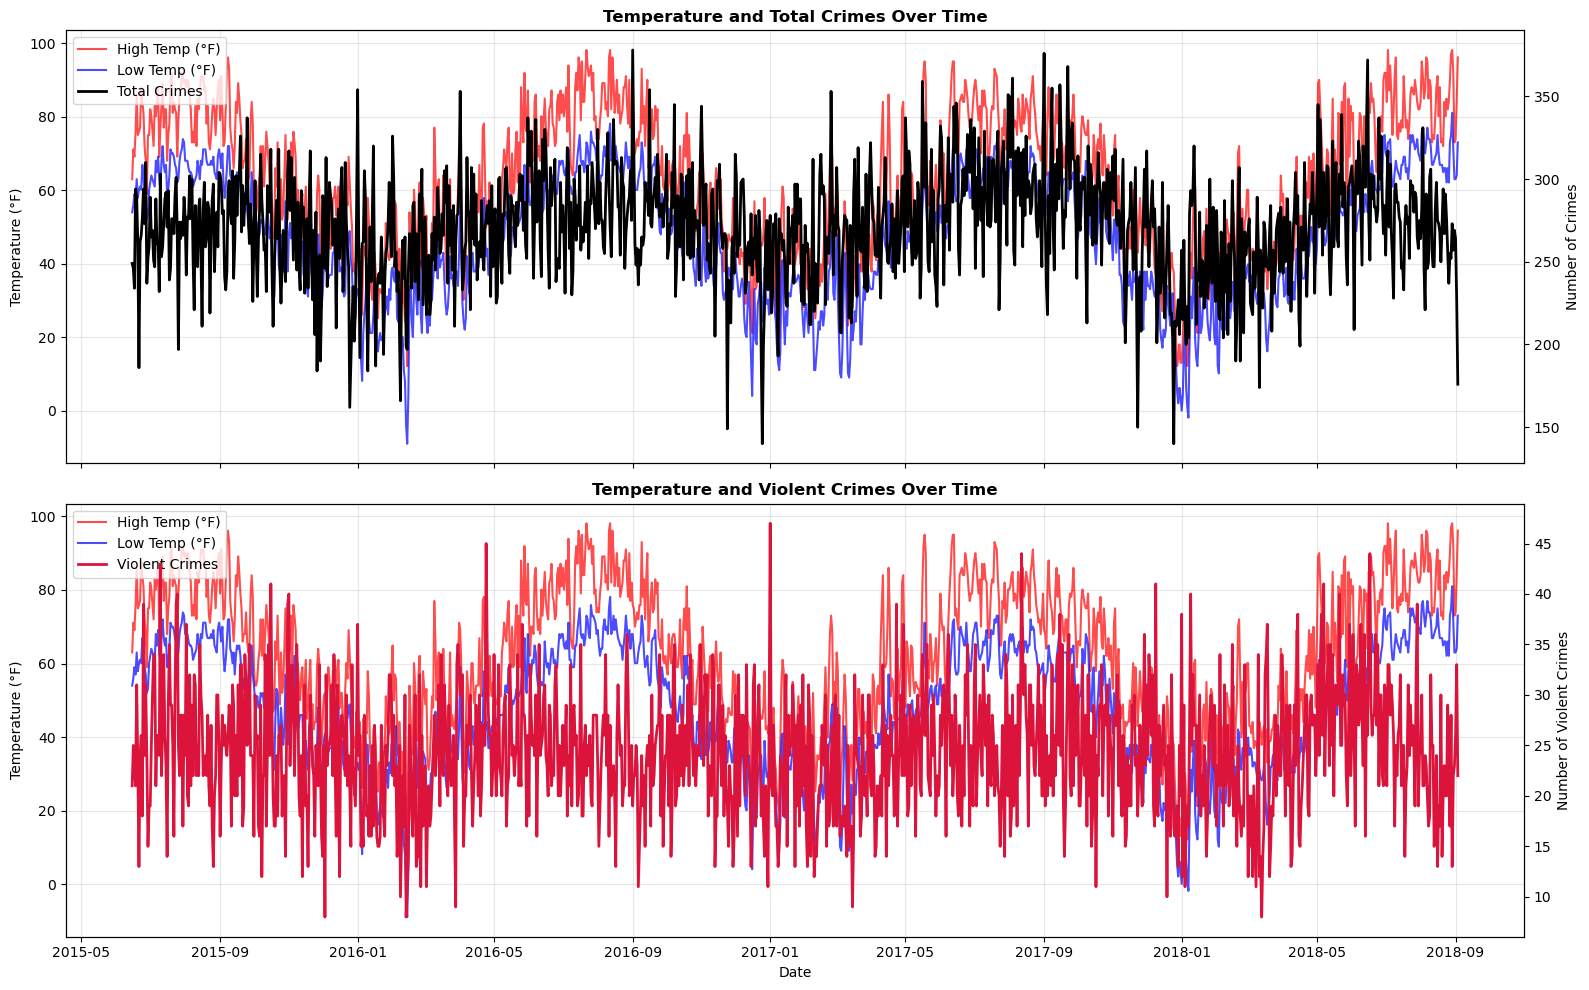

In [24]:
# Time series: Crime and Temperature over time
cw_time_series = crime_weather.select("date", "total_crimes", "violent_crimes", 
                                     "high_f", "low_f", "temp_range") \
                             .orderBy("date") \
                             .toPandas()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Temperature and Total Crimes
ax1_twin = ax1.twinx()
line1 = ax1.plot(cw_time_series['date'], cw_time_series['high_f'], 
                label='High Temp (°F)', color='red', alpha=0.7)
line2 = ax1.plot(cw_time_series['date'], cw_time_series['low_f'], 
                label='Low Temp (°F)', color='blue', alpha=0.7)
line3 = ax1_twin.plot(cw_time_series['date'], cw_time_series['total_crimes'], 
                     label='Total Crimes', color='black', linewidth=2)

ax1.set_ylabel('Temperature (°F)', color='black')
ax1_twin.set_ylabel('Number of Crimes', color='black')
ax1.set_title('Temperature and Total Crimes Over Time', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Plot 2: Temperature and Violent Crimes
ax2_twin = ax2.twinx()
ax2.plot(cw_time_series['date'], cw_time_series['high_f'], 
         label='High Temp (°F)', color='red', alpha=0.7)
ax2.plot(cw_time_series['date'], cw_time_series['low_f'], 
         label='Low Temp (°F)', color='blue', alpha=0.7)
line4 = ax2_twin.plot(cw_time_series['date'], cw_time_series['violent_crimes'], 
                     label='Violent Crimes', color='crimson', linewidth=2)

ax2.set_ylabel('Temperature (°F)', color='black')
ax2_twin.set_ylabel('Number of Violent Crimes', color='black')
ax2.set_xlabel('Date')
ax2.set_title('Temperature and Violent Crimes Over Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Combine legends for plot 2
lines2 = line1 + line2 + line4
labels2 = [l.get_label() for l in lines2]
ax2.legend(lines2, labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


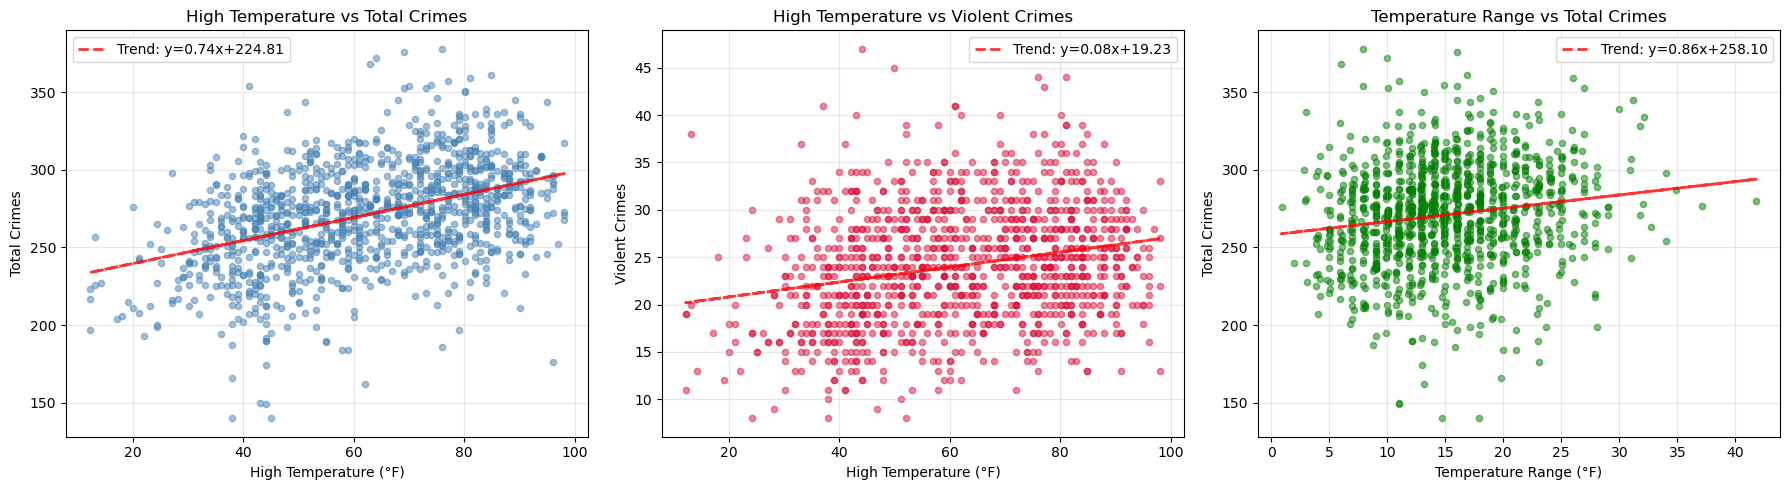

In [25]:
# Scatter plot: Temperature vs Crime
cw_scatter = crime_weather.select("high_f", "low_f", "temp_range", 
                                  "total_crimes", "violent_crimes", "property_crimes") \
                          .toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# High temperature vs Total crimes
axes[0].scatter(cw_scatter['high_f'], cw_scatter['total_crimes'], 
               alpha=0.5, s=20, color='steelblue')
axes[0].set_xlabel('High Temperature (°F)')
axes[0].set_ylabel('Total Crimes')
axes[0].set_title('High Temperature vs Total Crimes')
axes[0].grid(True, alpha=0.3)
# Add trend line
z = np.polyfit(cw_scatter['high_f'].dropna(), 
               cw_scatter['total_crimes'].dropna(), 1)
p = np.poly1d(z)
axes[0].plot(cw_scatter['high_f'], p(cw_scatter['high_f']), 
            "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
axes[0].legend()

# High temperature vs Violent crimes
axes[1].scatter(cw_scatter['high_f'], cw_scatter['violent_crimes'], 
               alpha=0.5, s=20, color='crimson')
axes[1].set_xlabel('High Temperature (°F)')
axes[1].set_ylabel('Violent Crimes')
axes[1].set_title('High Temperature vs Violent Crimes')
axes[1].grid(True, alpha=0.3)
# Add trend line
z = np.polyfit(cw_scatter['high_f'].dropna(), 
               cw_scatter['violent_crimes'].dropna(), 1)
p = np.poly1d(z)
axes[1].plot(cw_scatter['high_f'], p(cw_scatter['high_f']), 
            "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
axes[1].legend()

# Temperature range vs Total crimes
axes[2].scatter(cw_scatter['temp_range'], cw_scatter['total_crimes'], 
               alpha=0.5, s=20, color='green')
axes[2].set_xlabel('Temperature Range (°F)')
axes[2].set_ylabel('Total Crimes')
axes[2].set_title('Temperature Range vs Total Crimes')
axes[2].grid(True, alpha=0.3)
# Add trend line
z = np.polyfit(cw_scatter['temp_range'].dropna(), 
               cw_scatter['total_crimes'].dropna(), 1)
p = np.poly1d(z)
axes[2].plot(cw_scatter['temp_range'], p(cw_scatter['temp_range']), 
            "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()


In [26]:
# Crime by Season
crime_by_season = crime_weather_temp.groupBy("season") \
                                    .agg(avg("total_crimes").alias("avg_daily_crimes"),
                                         avg("violent_crimes").alias("avg_violent_crimes"),
                                         avg("property_crimes").alias("avg_property_crimes"),
                                         avg("shootings").alias("avg_shootings"),
                                         avg("high_f").alias("avg_high_temp"),
                                         count("*").alias("days")) \
                                    .orderBy("avg_high_temp")

print("Crime Statistics by Season:")
crime_by_season.show()


Crime Statistics by Season:
+------+------------------+------------------+-------------------+------------------+------------------+----+
|season|  avg_daily_crimes|avg_violent_crimes|avg_property_crimes|     avg_shootings|     avg_high_temp|days|
+------+------------------+------------------+-------------------+------------------+------------------+----+
|Winter|253.54074074074074| 22.55185185185185| 51.425925925925924|0.8703703703703703|42.244814814814845| 270|
|Spring|269.67753623188406| 24.06159420289855|  51.08695652173913|0.6557971014492754| 55.84384057971017| 276|
|  Fall|275.17028985507244|24.344202898550726|               58.0|0.8623188405797102| 64.62536231884057| 276|
|Summer| 282.3135593220339| 25.25423728813559|  60.60734463276836|1.0310734463276836| 80.89887005649717| 354|
+------+------------------+------------------+-------------------+------------------+------------------+----+



In [27]:
# Load and process GeoJSON data
# This section demonstrates how to work with GeoJSON in PySpark context
import geopandas as gpd
def load_geojson_to_spark(geojson_path, spark_session):
    """
    Load GeoJSON file and convert to Spark DataFrame
    Handles different geometry types (Point, Polygon, MultiPolygon, etc.)
    """
    try:
        # Read GeoJSON with geopandas
        gdf = gpd.read_file(geojson_path)
        
        print(f"Loaded GeoJSON with {len(gdf)} features")
        print(f"Geometry types: {gdf.geometry.type.unique()}")
        print(f"Columns: {list(gdf.columns)}")
        
        # Handle different geometry types
        # For Points: extract x, y coordinates
        # For Polygons/MultiPolygons: extract centroid coordinates
        if gdf.geometry.type.iloc[0] == 'Point':
            gdf['longitude'] = gdf.geometry.x
            gdf['latitude'] = gdf.geometry.y
        else:
            # For Polygons and other geometries, use centroid
            gdf['longitude'] = gdf.geometry.centroid.x
            gdf['latitude'] = gdf.geometry.centroid.y
            # Also store geometry as WKT (Well-Known Text) for reference
            gdf['geometry_wkt'] = gdf.geometry.apply(lambda x: x.wkt if x is not None else None)
        
        # Convert to pandas and then to Spark
        # Drop the geometry column (can't be directly stored in Spark)
        pdf = gdf.drop('geometry', axis=1) if 'geometry' in gdf.columns else gdf
        
        # Convert to Spark DataFrame
        spark_df = spark_session.createDataFrame(pdf)
        
        print(f"Successfully converted to Spark DataFrame with {spark_df.count()} rows")
        print("\nFirst few rows:")
        spark_df.show(5, truncate=False)
        
        return spark_df, gdf
    except Exception as e:
        print(f"Error loading GeoJSON: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# Load your Boston Neighborhoods GeoJSON file
geojson_path = "/Users/tripa/Desktop/BU/Fall 2025/Big data/Term Project/Boston_Neighborhoods.geojson"
geo_spark_df, geo_gdf = load_geojson_to_spark(geojson_path, spark)

if geo_spark_df is not None:
    print("\nGeoJSON loaded successfully!")
    print(f"Spark DataFrame schema:")
    geo_spark_df.printSchema()
else:
    print("\nFailed to load GeoJSON file")


Loaded GeoJSON with 26 features
Geometry types: ['MultiPolygon' 'Polygon']
Columns: ['OBJECTID', 'Name', 'Acres', 'Neighborhood_ID', 'SqMiles', 'ShapeSTArea', 'ShapeSTLength', 'geometry']


Successfully converted to Spark DataFrame with 26 rows

First few rows:
+--------+-------------+-------------+---------------+-------+--------------------+------------------+------------------+------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [28]:
# Use the actual GeoDataFrame (geo_gdf) loaded above instead of sample data
# The variable 'geo_gdf' is your actual geopandas GeoDataFrame loaded earlier.
# You can use it directly for analysis, visualization, or conversion to Spark:

print("First few rows of your actual GeoDataFrame (geo_gdf):")
print(geo_gdf.head())

# Convert to GeoDataFrame
if 'geopandas' in globals():
    from shapely.geometry import Point
    
    # Create sample data
    points = [Point(-71.0589, 42.3601)]  # Boston
    sample_data = {
        'station_id': ['BOS001'],
        'station_name': ['Boston Weather Station']
    }
    
    sample_gdf = gpd.GeoDataFrame(sample_data, geometry=points, crs='EPSG:4326')
    
    # Convert to Spark DataFrame
    sample_pdf = sample_gdf.drop('geometry', axis=1)
    sample_pdf['longitude'] = sample_gdf.geometry.x
    sample_pdf['latitude'] = sample_gdf.geometry.y
    
    sample_spark_df = spark.createDataFrame(sample_pdf)
    print("Sample GeoJSON data created and converted to Spark DataFrame:")
    sample_spark_df.show()
else:
    print("Geopandas not available. Install with: pip install geopandas")


First few rows of your actual GeoDataFrame (geo_gdf):
   OBJECTID           Name        Acres Neighborhood_ID  SqMiles  \
0        27     Roslindale  1605.568237              15     2.51   
1        28  Jamaica Plain  2519.245394              11     3.94   
2        29   Mission Hill   350.853564              13     0.55   
3        30       Longwood   188.611947              28     0.29   
4        31    Bay Village    26.539839              33     0.04   

    ShapeSTArea  ShapeSTLength  \
0  6.993827e+07   53563.912597   
1  1.097379e+08   56349.937161   
2  1.528312e+07   17918.724113   
3  8.215904e+06   11908.757148   
4  1.156071e+06    4650.635493   

                                            geometry  longitude   latitude  \
0  MULTIPOLYGON (((-71.12593 42.27201, -71.12611 ... -71.126663  42.282524   
1  POLYGON ((-71.10499 42.3261, -71.10503 42.3261... -71.115097  42.307770   
2  POLYGON ((-71.09043 42.33577, -71.0905 42.3357... -71.102607  42.331741   
3  POLYGON ((-71.098

In [ ]:
## 4. Spatial Analysis: Serious Crimes per Neighborhood
# Load Boston Neighborhoods GeoJSON
geojson_path = "/Users/tripa/Desktop/BU/Fall 2025/Big data/Term Project/Boston_Neighborhoods.geojson"
geo = gpd.read_file(geojson_path)

print(f"Loaded {len(geo)} neighborhoods")
print(f"Neighborhood columns: {geo.columns.tolist()}")
geo.head(2)

Loaded 26 neighborhoods
Neighborhood columns: ['OBJECTID', 'Name', 'Acres', 'Neighborhood_ID', 'SqMiles', 'ShapeSTArea', 'ShapeSTLength', 'geometry']


,OBJECTID,Name,Acres,Neighborhood_ID,SqMiles,ShapeSTArea,ShapeSTLength,geometry
0,27,Roslindale,1605.568237,15,2.51,6.993827e+07,53563.912597,"MULTIPOLYGON (((-71.12593 42.27201, -71.12611 ..."
1,28,Jamaica Plain,2519.245394,11,3.94,1.097379e+08,56349.937161,"POLYGON ((-71.10499 42.3261, -71.10503 42.3261..."


In [30]:
from pyspark.sql.functions import col, count, desc

# Load crime data if not already loaded
crime_path = "/Users/tripa/Desktop/BU/Fall 2025/Big data/Term Project/preprocessed_crime_data.csv"
crime_df = spark.read.csv(crime_path, header=True, inferSchema=True)

# Define serious crimes based on OFFENSE_CODE_GROUP
serious_crime_groups = [
    'Homicide',
    'Aggravated Assault',
    'Robbery',
    'Rape',
    'Sexual Assault',
    'Commercial Burglary',
    'Residential Burglary',
    'Auto Theft',
    'Larceny',
    'Larceny From Motor Vehicle'
]

# Filter for serious crimes
serious_crimes = crime_df.filter(
    col("OFFENSE_CODE_GROUP").isin(serious_crime_groups)
)

print(f"Total crimes: {crime_df.count()}")
print(f"Serious crimes: {serious_crimes.count()}")

Total crimes: 319050
Serious crimes: 61167


In [31]:
# Filter for valid coordinates (Boston area: Lat > 40, Long < -69)
# Use Lat_Clean and Long_Clean if available, otherwise use Lat and Long
if "Lat_Clean" in serious_crimes.columns and "Long_Clean" in serious_crimes.columns:
    serious_filtered = serious_crimes.filter(
        (col("Lat_Clean") > 40) & (col("Long_Clean") < -69) &
        (col("Lat_Clean").isNotNull()) & (col("Long_Clean").isNotNull())
    ).select(
        "INCIDENT_NUMBER", "OFFENSE_CODE_GROUP", 
        col("Lat_Clean").alias("Lat"), 
        col("Long_Clean").alias("Long")
    )
else:
    serious_filtered = serious_crimes.filter(
        (col("Lat") > 40) & (col("Long") < -69) &
        (col("Lat").isNotNull()) & (col("Long").isNotNull())
    ).select(
        "INCIDENT_NUMBER", "OFFENSE_CODE_GROUP", "Lat", "Long"
    )

print(f"Serious crimes with valid coordinates: {serious_filtered.count()}")

# Convert to pandas for spatial operations with geopandas
serious_pd = serious_filtered.toPandas()

# Create GeoDataFrame from crime points
serious_gdf = gpd.GeoDataFrame(
    serious_pd,
    geometry=gpd.points_from_xy(serious_pd['Long'], serious_pd['Lat']),
    crs='EPSG:4326'
)

print(f"\nCreated GeoDataFrame with {len(serious_gdf)} crime points")
print(f"Coordinate Reference System: {serious_gdf.crs}")
serious_gdf.head(2)


Serious crimes with valid coordinates: 61050

Created GeoDataFrame with 61050 crime points
Coordinate Reference System: EPSG:4326


,INCIDENT_NUMBER,OFFENSE_CODE_GROUP,Lat,Long,geometry
0,I182062810,Aggravated Assault,42.277180,-71.098709,POINT (-71.09871 42.27718)
1,I182050499,Aggravated Assault,42.305407,-71.065471,POINT (-71.06547 42.30541)


In [32]:
# Ensure both GeoDataFrames have the same CRS
if serious_gdf.crs != geo.crs:
    serious_gdf = serious_gdf.to_crs(geo.crs)

# Perform spatial join: assign crimes to neighborhoods
# Using 'within' operation to find which neighborhood each crime point falls into
intersects_gdf = gpd.sjoin(serious_gdf, geo, predicate='within', how='right')

print(f"Total neighborhoods: {len(geo)}")
print(f"Crimes assigned to neighborhoods: {intersects_gdf['INCIDENT_NUMBER'].notna().sum()}")
print(f"\nFirst few rows of joined data:")
display(intersects_gdf.head(2))


Total neighborhoods: 26
Crimes assigned to neighborhoods: 58422

First few rows of joined data:


,index_left,INCIDENT_NUMBER,OFFENSE_CODE_GROUP,Lat,Long,OBJECTID,Name,Acres,Neighborhood_ID,SqMiles,ShapeSTArea,ShapeSTLength,geometry
0,13.0,I172093639,Aggravated Assault,42.292556,-71.119742,27,Roslindale,1605.568237,15,2.51,6.993827e+07,53563.912597,"MULTIPOLYGON (((-71.12593 42.27201, -71.12611 ..."
0,34.0,I162066921,Aggravated Assault,42.287726,-71.106787,27,Roslindale,1605.568237,15,2.51,6.993827e+07,53563.912597,"MULTIPOLYGON (((-71.12593 42.27201, -71.12611 ..."


In [33]:
# Count serious crimes per neighborhood
# Group by neighborhood name and count incidents
crimes_per_nb = intersects_gdf.groupby('Name')['INCIDENT_NUMBER'].count().reset_index()
crimes_per_nb.columns = ['Name', 'Crimes']

# Merge with neighborhood geometry
crimes_per_nb = geo.merge(crimes_per_nb, on='Name', how='left')

# Fill NaN values (neighborhoods with no crimes) with 0
crimes_per_nb['Crimes'] = crimes_per_nb['Crimes'].fillna(0).astype(int)

# Calculate representative point coordinates for labeling
crimes_per_nb['coords'] = crimes_per_nb['geometry'].apply(
    lambda x: x.representative_point().coords[:] if x is not None else None
)
crimes_per_nb['coords'] = crimes_per_nb['coords'].apply(
    lambda x: x[0] if x is not None else None
)

print("Serious Crimes per Neighborhood:")
print("=" * 70)
display(crimes_per_nb[['Name', 'Crimes']].sort_values('Crimes', ascending=False))

print(f"\nTotal neighborhoods: {len(crimes_per_nb)}")
print(f"Neighborhoods with crimes: {(crimes_per_nb['Crimes'] > 0).sum()}")
print(f"Total serious crimes: {crimes_per_nb['Crimes'].sum()}")
print(f"Average crimes per neighborhood: {crimes_per_nb['Crimes'].mean():.2f}")

# Display the full GeoDataFrame with geometry
print("\nFull crimes_per_nb GeoDataFrame (first 5 rows):")
display(crimes_per_nb.head())


Serious Crimes per Neighborhood:


,Name,Crimes
21,Dorchester,12079
8,Roxbury,6591
15,Downtown,5293
10,Back Bay,5275
1,Jamaica Plain,3088
16,Fenway,2735
9,South End,2725
23,South Boston,2715
11,East Boston,2129
20,Mattapan,2088



Total neighborhoods: 26
Neighborhoods with crimes: 25
Total serious crimes: 58422
Average crimes per neighborhood: 2247.00

Full crimes_per_nb GeoDataFrame (first 5 rows):


,OBJECTID,Name,Acres,Neighborhood_ID,SqMiles,ShapeSTArea,ShapeSTLength,geometry,Crimes,coords
0,27,Roslindale,1605.568237,15,2.51,6.993827e+07,53563.912597,"MULTIPOLYGON (((-71.12593 42.27201, -71.12611 ...",1316,"(-71.12383770493841, 42.283116123534356)"
1,28,Jamaica Plain,2519.245394,11,3.94,1.097379e+08,56349.937161,"POLYGON ((-71.10499 42.3261, -71.10503 42.3261...",3088,"(-71.11741230311375, 42.308246349570766)"
2,29,Mission Hill,350.853564,13,0.55,1.528312e+07,17918.724113,"POLYGON ((-71.09043 42.33577, -71.0905 42.3357...",1251,"(-71.10414988317825, 42.33181646459366)"
3,30,Longwood,188.611947,28,0.29,8.215904e+06,11908.757148,"POLYGON ((-71.09811 42.33673, -71.09832 42.337...",359,"(-71.10484838512677, 42.33903747754854)"
4,31,Bay Village,26.539839,33,0.04,1.156071e+06,4650.635493,"POLYGON ((-71.06663 42.34878, -71.06663 42.348...",215,"(-71.0687104592235, 42.34934955969946)"


In [34]:

from pyspark.sql.functions import col, to_date

# 1. Attach daily temperature to each serious crime (Spark)

# Ensure serious_crimes has a date column we can join on
serious_with_date = serious_crimes.withColumn(
    "crime_date",
    to_date(col("OCCURRED_ON_DATE"))  # extract date from timestamp
)

# Weather dataframe `df` already has: date_parsed, high_f, low_f, temp_range
weather_for_join = df.select(
    col("date_parsed").alias("crime_date"),
    "high_f",
    "low_f",
    "temp_range"
)

# Join serious crimes with weather by date
serious_with_temp = serious_with_date.join(weather_for_join, on="crime_date", how="left")

# 2. Filter for valid coordinates in Boston and keep temperature

if "Lat_Clean" in serious_with_temp.columns and "Long_Clean" in serious_with_temp.columns:
    serious_temp_filtered = serious_with_temp.filter(
        (col("Lat_Clean") > 40) & (col("Long_Clean") < -69) &
        col("Lat_Clean").isNotNull() & col("Long_Clean").isNotNull()
    ).select(
        "INCIDENT_NUMBER",
        "OFFENSE_CODE_GROUP",
        col("Lat_Clean").alias("Lat"),
        col("Long_Clean").alias("Long"),
        "high_f"
    )
else:
    serious_temp_filtered = serious_with_temp.filter(
        (col("Lat") > 40) & (col("Long") < -69) &
        col("Lat").isNotNull() & col("Long").isNotNull()
    ).select(
        "INCIDENT_NUMBER",
        "OFFENSE_CODE_GROUP",
        "Lat",
        "Long",
        "high_f"
    )

print(f"Serious crimes with temp & valid coords: {serious_temp_filtered.count()}")

# 3. Convert to GeoDataFrame and spatial join with neighborhoods (geopandas)

serious_temp_pd = serious_temp_filtered.toPandas()

serious_temp_gdf = gpd.GeoDataFrame(
    serious_temp_pd,
    geometry=gpd.points_from_xy(serious_temp_pd["Long"], serious_temp_pd["Lat"]),
    crs="EPSG:4326"
)

# Match CRS with neighborhood GeoDataFrame `geo`
if serious_temp_gdf.crs != geo.crs:
    serious_temp_gdf = serious_temp_gdf.to_crs(geo.crs)

# Spatial join: assign each crime to a neighborhood
intersects_temp = gpd.sjoin(serious_temp_gdf, geo, predicate="within", how="right")

# 4. Aggregate: crimes per neighborhood + avg temperature on crime days

stats_nb = (
    intersects_temp
    .groupby("Name")
    .agg(
        Crimes=("INCIDENT_NUMBER", "count"),
        AvgTemp=("high_f", "mean")  # average daily high temp when crimes occurred
    )
    .reset_index()
)

# Merge back with neighborhood geometry for plotting
crimes_temp_per_nb = geo.merge(stats_nb, on="Name", how="left")

# Handle neighborhoods with no crimes
crimes_temp_per_nb["Crimes"] = crimes_temp_per_nb["Crimes"].fillna(0).astype(int)
crimes_temp_per_nb["AvgTemp"] = crimes_temp_per_nb["AvgTemp"].astype(float)

# Optional: coords for labels on a map
crimes_temp_per_nb["coords"] = crimes_temp_per_nb["geometry"].apply(
    lambda x: x.representative_point().coords[:] if x is not None else None
)
crimes_temp_per_nb["coords"] = crimes_temp_per_nb["coords"].apply(
    lambda x: x[0] if x is not None else None
)

print("Crimes and average temperature per neighborhood:")
display(
    crimes_temp_per_nb[["Name", "Crimes", "AvgTemp"]]
        .sort_values("Crimes", ascending=False)
)



Serious crimes with temp & valid coords: 61050


Crimes and average temperature per neighborhood:


,Name,Crimes,AvgTemp
21,Dorchester,12079,63.536264
8,Roxbury,6591,64.230337
15,Downtown,5293,64.113138
10,Back Bay,5275,62.752768
1,Jamaica Plain,3088,64.116926
16,Fenway,2735,64.745788
9,South End,2725,64.144342
23,South Boston,2715,64.564959
11,East Boston,2129,64.171590
20,Mattapan,2088,64.460201


In [35]:
# Statistical summary by temperature category
print("Weather Statistics by Temperature Category:")
df.groupBy("temp_category") \
  .agg(count("*").alias("count"),
       avg("high_f").alias("avg_high"),
       avg("low_f").alias("avg_low"),
       avg("precip_inch").alias("avg_precip"),
       avg("snow_inch").alias("avg_snow")) \
  .orderBy("temp_category") \
  .show()


Weather Statistics by Temperature Category:
+-------------+-----+------------------+------------------+-------------------+--------------------+
|temp_category|count|          avg_high|           avg_low|         avg_precip|            avg_snow|
+-------------+-----+------------------+------------------+-------------------+--------------------+
|         Cold|  385| 41.40181818181817|29.063636363636462|0.12104675324675315|  0.3112184967100178|
|         Cool|  462|59.228577956199565| 44.63599141320186| 0.1383022766586851| 0.00295404490393979|
|     Freezing|   86| 25.06395348837209|12.143023255813969|0.08488372093023257|  1.4761346946757716|
|          Hot|  137| 90.12481751824822| 68.65328467153284|0.05356934306569345|7.299270072992701E-6|
|         Warm|  390| 77.52948717948722| 60.95333333333334|0.10085641025641025|                 0.0|
+-------------+-----+------------------+------------------+-------------------+--------------------+



In [ ]:
# 5. Predicting crime category and risky areas using PySpark ML

from pyspark.sql.functions import to_date, col
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Build a modeling dataset: join crime with daily weather

# Ensure we have a date column on crimes
crime_ml = crime_df.withColumn(
    "crime_date",
    to_date(col("OCCURRED_ON_DATE"))
)

# Weather data already has daily features
weather_ml = df.select(
    col("date_parsed").alias("crime_date"),
    "high_f",
    "low_f",
    "precip_inch"
)

# Inner join keeps only days that exist in both datasets
crime_weather_ml = crime_ml.join(weather_ml, on="crime_date", how="inner")

# Keep useful columns and drop rows with missing labels / key features
model_df = (crime_weather_ml
    .select(
        "DISTRICT",          # area (police district)
        "HOUR",              # hour of day
        "IS_WEEKEND",        # weekend flag (0/1)
        "SEASON",            # season
        "high_f", "low_f", "precip_inch",  # weather
        "OFFENSE_CATEGORY"   # label: Violent / Property / Other / Traffic
    )
    .na.drop(subset=["DISTRICT", "HOUR", "IS_WEEKEND", "SEASON", "high_f", "OFFENSE_CATEGORY"])
)

print(f"Total records for modeling: {model_df.count()}")

# 2. Encode categorical variables and assemble features

categorical_cols = ["DISTRICT", "SEASON", "IS_WEEKEND"]
label_col = "OFFENSE_CATEGORY"

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols + [label_col]
]

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in categorical_cols],
    outputCols=[f"{c}_oh" for c in categorical_cols]
)

feature_cols = ["HOUR", "high_f", "low_f", "precip_inch"] + [f"{c}_oh" for c in categorical_cols]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# 3. Define classifier (multi-class)

rf = RandomForestClassifier(
    labelCol=f"{label_col}_idx",
    featuresCol="features",
    numTrees=50,
    maxDepth=10,
    seed=42
)

pipeline = Pipeline(stages=indexers + [encoder, assembler, rf])

# 4. Train / test split

train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)
print(f"Training rows: {train_df.count()}, Test rows: {test_df.count()}")

# Fit model
model = pipeline.fit(train_df)

# 5. Evaluate model

predictions = model.transform(test_df)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol=f"{label_col}_idx",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator_acc.evaluate(predictions)
print(f"Test Accuracy (OFFENSE_CATEGORY prediction): {accuracy:.4f}")

# Optional: F1 score for additional insight
from pyspark.ml.evaluation import MulticlassClassificationEvaluator as MCE

evaluator_f1 = MCE(
    labelCol=f"{label_col}_idx",
    predictionCol="prediction",
    metricName="f1"
)


Total records for modeling: 318773
Training rows: 255013, Test rows: 63760


25/11/28 20:41:49 WARN DAGScheduler: Broadcasting large task binary with size 1136.7 KiB
25/11/28 20:41:51 WARN DAGScheduler: Broadcasting large task binary with size 1851.0 KiB
25/11/28 20:41:54 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/11/28 20:41:56 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
25/11/28 20:42:01 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


Test Accuracy (OFFENSE_CATEGORY prediction): 0.5385


25/11/28 20:42:03 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


Test F1-score: 0.3770


In [37]:
# 7. Make risky areas and times human-readable (area name + explicit hour)

from pyspark.sql.functions import when, udf, StringType, round as spark_round, sum as spark_sum, col

# Map Boston police district codes to approximate neighborhood/area names
area_name_col = (
    when(col("DISTRICT") == "A1",  "Downtown / Beacon Hill")
    .when(col("DISTRICT") == "A7",  "East Boston")
    .when(col("DISTRICT") == "A15", "Charlestown")
    .when(col("DISTRICT") == "B2",  "Roxbury")
    .when(col("DISTRICT") == "B3",  "Mattapan")
    .when(col("DISTRICT") == "C6",  "South Boston")
    .when(col("DISTRICT") == "C11", "Dorchester")
    .when(col("DISTRICT") == "D4",  "South End / Back Bay")
    .when(col("DISTRICT") == "E5",  "West Roxbury")
    .when(col("DISTRICT") == "E13", "Jamaica Plain")
    .when(col("DISTRICT") == "E18", "Hyde Park")
    .otherwise(col("DISTRICT"))
)

# UDF to convert hour (0-23) to explicit time label like "22:00-23:00 (10 PM)"
@udf(StringType())
def hour_label(h):
    if h is None:
        return None
    try:
        h_int = int(h)
    except Exception:
        return None
    start_h = h_int % 24
    end_h = (h_int + 1) % 24

    def to_ampm(hr):
        suffix = "AM" if hr < 12 else "PM"
        hour12 = hr % 12
        if hour12 == 0:
            hour12 = 12
        return f"{hour12} {suffix}"

    return f"{start_h:02d}:00-{end_h:02d}:00 ({to_ampm(start_h)})"

# Build risk_df directly from existing `predictions` (model outputs)
# Assumes `predictions` has: DISTRICT, HOUR, OFFENSE_CATEGORY, high_f

risk_df = (
    predictions
    .withColumn(
        "temp_bucket",
        when(col("high_f") < 32, "Freezing")
        .when(col("high_f") < 50, "Cold")
        .when(col("high_f") < 70, "Cool")
        .when(col("high_f") < 85, "Warm")
        .otherwise("Hot")
    )
    .groupBy("DISTRICT", "HOUR", "temp_bucket")
    .agg(
        # violent_rate = fraction of crimes that are Violent
        (spark_sum(when(col("OFFENSE_CATEGORY") == "Violent", 1).otherwise(0)) /
         spark_sum(when(col("OFFENSE_CATEGORY").isNotNull(), 1).otherwise(0))).alias("violent_rate"),
        spark_sum(when(col("OFFENSE_CATEGORY").isNotNull(), 1).otherwise(0)).alias("n_events")
    )
    .filter(col("n_events") >= 30)  # keep only combinations with enough data
)

# Add human-readable columns and temperature range description
risk_pretty = (risk_df
    .withColumn("AreaName", area_name_col)
    .withColumn("HourLabel", hour_label(col("HOUR")))
    .withColumn(
        "TempRange",
        when(col("temp_bucket") == "Freezing", "< 32°F")
        .when(col("temp_bucket") == "Cold", "32–49°F")
        .when(col("temp_bucket") == "Cool", "50–69°F")
        .when(col("temp_bucket") == "Warm", "70–84°F")
        .otherwise("≥ 85°F")
    )
    .withColumn("violent_rate", spark_round(col("violent_rate"), 2))  # 2 decimal places
)

print("Top 10 high-risk (area name, time window, temperature) combinations:")
risk_pretty.select(
    "AreaName",
    "HourLabel",
    "temp_bucket",
    "TempRange",
    "violent_rate",
    "n_events",
).orderBy(col("violent_rate").desc()).show(10, truncate=False)

Top 10 high-risk (area name, time window, temperature) combinations:


+----------------------+-------------------+-----------+---------+------------+--------+
|AreaName              |HourLabel          |temp_bucket|TempRange|violent_rate|n_events|
+----------------------+-------------------+-----------+---------+------------+--------+
|Downtown / Beacon Hill|02:00-03:00 (2 AM) |Cold       |32–49°F  |0.36        |72      |
|Downtown / Beacon Hill|01:00-02:00 (1 AM) |Hot        |≥ 85°F   |0.3         |40      |
|Downtown / Beacon Hill|01:00-02:00 (1 AM) |Cool       |50–69°F  |0.29        |112     |
|Downtown / Beacon Hill|03:00-04:00 (3 AM) |Warm       |70–84°F  |0.29        |49      |
|Downtown / Beacon Hill|02:00-03:00 (2 AM) |Hot        |≥ 85°F   |0.27        |30      |
|South End / Back Bay  |23:00-00:00 (11 PM)|Hot        |≥ 85°F   |0.26        |31      |
|Downtown / Beacon Hill|03:00-04:00 (3 AM) |Cold       |32–49°F  |0.26        |38      |
|Downtown / Beacon Hill|01:00-02:00 (1 AM) |Warm       |70–84°F  |0.26        |92      |
|Downtown / Beacon Hi

## Interactive Query

In [38]:
# 9. Interactive query: given a temperature, show unsafe areas and time ranges

# Ask only for expected high temperature
input_temp_str = input("Enter expected high temperature (°F) for that day: ").strip()

try:
    input_temp = float(input_temp_str)
except ValueError:
    print("Invalid temperature. Please enter a numeric °F value.")
    input_temp = None

if input_temp is not None:
    # Map temperature to the same bucket logic used earlier
    if input_temp < 32:
        temp_bucket_input = "Freezing"
    elif 32 <= input_temp < 50:
        temp_bucket_input = "Cold"
    elif 50 <= input_temp < 70:
        temp_bucket_input = "Cool"
    elif 70 <= input_temp < 85:
        temp_bucket_input = "Warm"
    else:
        temp_bucket_input = "Hot"

    print(f"\nUsing temperature bucket: {temp_bucket_input}")

    # Filter pre-computed risk table for that temperature bucket
    unsafe_df = (
        risk_pretty
        .filter(risk_pretty.temp_bucket == temp_bucket_input)
        .orderBy(risk_pretty.violent_rate.desc(), risk_pretty.n_events.desc())
    )

    if unsafe_df.count() == 0:
        print(f"\nNo historical data for temperature bucket '{temp_bucket_input}'.")
    else:
        print("\nBased on historical patterns, the following area/time combinations")
        print("have the highest violent crime rates for similar temperature conditions:\n")

        unsafe_df.select(
            "AreaName",      # human-readable area
            "HourLabel",     # explicit 1-hour window
            "TempRange",     # e.g., 70–84°F
            "violent_rate",  # fraction of crimes that are violent (0–1), 2 decimals
            "n_events"       # number of historical events supporting this estimate
        ).show(15, truncate=False)
else:
    print("Skipping unsafe-area recommendation due to invalid temperature input.")


Using temperature bucket: Warm

Based on historical patterns, the following area/time combinations
have the highest violent crime rates for similar temperature conditions:

+----------------------+-------------------+---------+------------+--------+
|AreaName              |HourLabel          |TempRange|violent_rate|n_events|
+----------------------+-------------------+---------+------------+--------+
|Downtown / Beacon Hill|03:00-04:00 (3 AM) |70–84°F  |0.29        |49      |
|Downtown / Beacon Hill|01:00-02:00 (1 AM) |70–84°F  |0.26        |92      |
|Downtown / Beacon Hill|02:00-03:00 (2 AM) |70–84°F  |0.24        |99      |
|Downtown / Beacon Hill|23:00-00:00 (11 PM)|70–84°F  |0.24        |76      |
|D14                   |01:00-02:00 (1 AM) |70–84°F  |0.23        |35      |
|Roxbury               |02:00-03:00 (2 AM) |70–84°F  |0.22        |76      |
|South End / Back Bay  |02:00-03:00 (2 AM) |70–84°F  |0.22        |63      |
|South Boston          |22:00-23:00 (10 PM)|70–84°F  |0.

In [39]:
risk_pretty.printSchema()
risk_pretty.groupBy("temp_bucket").count().show()

root
 |-- DISTRICT: string (nullable = true)
 |-- HOUR: integer (nullable = true)
 |-- temp_bucket: string (nullable = false)
 |-- violent_rate: double (nullable = true)
 |-- n_events: long (nullable = true)
 |-- AreaName: string (nullable = true)
 |-- HourLabel: string (nullable = true)
 |-- TempRange: string (nullable = false)

+-----------+-----+
|temp_bucket|count|
+-----------+-----+
|       Cool|  216|
|       Cold|  193|
|        Hot|  103|
|       Warm|  224|
+-----------+-----+



## Statistical Significance

In [41]:
# 10. Test statistical significance of correlations between weather and total crime (PySpark)

from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression

# 1. Reuse the existing daily crime + weather dataset `crime_weather`
#    (already created earlier by joining `crime_daily` with weather `df`).

crime_weather_lr = (
    crime_weather
    .select(
        col("date").alias("crime_date"),
        "total_crimes",
        "high_f", "low_f", "precip_inch", "snow_inch"
    )
    .na.drop(subset=["total_crimes", "high_f", "low_f", "precip_inch", "snow_inch"])
)

print(f"Daily records for linear model: {crime_weather_lr.count()}")

# 2. Prepare features and label

feature_cols_lr = ["high_f", "low_f", "precip_inch", "snow_inch"]
assembler_lr = VectorAssembler(inputCols=feature_cols_lr, outputCol="features")

crime_weather_vec = assembler_lr.transform(crime_weather_lr)

# 3. Fit a linear regression model: total crimes ~ weather variables

lr = LinearRegression(
    labelCol="total_crimes",
    featuresCol="features",
    fitIntercept=True
)

lr_model = lr.fit(crime_weather_vec)

summary = lr_model.summary

print("\nLinear Regression Results: total_crimes ~ high_f + low_f + precip_inch + snow_inch")
print("--------------------------------------------------------------------------")
print(f"R^2 (coefficient of determination): {summary.r2:.4f}")
print(f"RMSE: {summary.rootMeanSquaredError:.4f}")
print("\nNote: Even with a stronger model, R² may stay moderate because weather + season")
print("      only capture part of what drives crime; other factors (events, policing,")
print("      demographics, etc.) are not in this dataset.")

print("\nCoefficients and p-values (testing significance of each weather variable):")
for name, coef, pval in zip(feature_cols_lr, lr_model.coefficients, summary.pValues[1:]):
    print(f"  {name:12s} -> coef = {coef:8.4f}, p-value = {pval:.4e}")

print("\nIntercept:")
print(f"  intercept = {lr_model.intercept:8.4f}, p-value = {summary.pValues[0]:.4e}")

print("\nInterpretation:")
print("  - Small p-values (e.g., < 0.05) indicate a statistically significant relationship")
print("    between that weather variable and daily total crime counts, after controlling")
print("    for the other variables in the model.")

Daily records for linear model: 1176


25/11/28 20:42:48 WARN Instrumentation: [a72ad79b] regParam is zero, which might cause numerical instability and overfitting.
25/11/28 20:42:48 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK



Linear Regression Results: total_crimes ~ high_f + low_f + precip_inch + snow_inch
--------------------------------------------------------------------------
R^2 (coefficient of determination): 0.1857
RMSE: 29.8581

Note: Even with a stronger model, R² may stay moderate because weather + season
      only capture part of what drives crime; other factors (events, policing,
      demographics, etc.) are not in this dataset.

Coefficients and p-values (testing significance of each weather variable):
  high_f       -> coef =   0.5413, p-value = 2.2419e-01
  low_f        -> coef =   0.1974, p-value = 8.2189e-03
  precip_inch  -> coef =  -8.2978, p-value = 1.7187e-02
  snow_inch    -> coef =  -2.5835, p-value = 0.0000e+00

Intercept:
  intercept = 229.2203, p-value = 2.4386e-04

Interpretation:
  - Small p-values (e.g., < 0.05) indicate a statistically significant relationship
    between that weather variable and daily total crime counts, after controlling
    for the other variables in th

In [43]:
# Stop Spark session
spark.stop()
print("Spark session stopped")


Spark session stopped
